In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
from jaxtyping import Float

import dismech_jax as djx

from util_multiset import TripletModel, validate_model, train_model, get_base_rod
from animate import animate

jax.config.update("jax_enable_x64", True)


In [2]:
class MLP(eqx.Module):
    layer1: eqx.nn.Linear
    layer2: eqx.nn.Linear

    def __init__(self, in_features: int, hidden_size: int, key: jax.Array):
        key1, key2 = jax.random.split(key)
        self.layer1 = eqx.nn.Linear(in_features, hidden_size, key=key1)
        self.layer2 = eqx.nn.Linear(hidden_size, 1, key=key2)

        self.layer1 = eqx.tree_at(
            lambda l: l.weight, self.layer1, self.layer1.weight * 1e-2
        )
        self.layer2 = eqx.tree_at(
            lambda l: l.weight, self.layer2, self.layer2.weight * 1e-2
        )

    def __call__(self, x: jax.Array) -> jax.Array:
        x = jax.nn.softplus(self.layer1(x))
        x = self.layer2(x)
        return jax.nn.softplus(x[0])


class Example(TripletModel):
    K: jax.Array  # = eqx.field(static=True)
    mlp: MLP

    def __init__(self, der_K: jax.Array, key: jax.Array):
        self.K = der_K
        self.mlp = MLP(5, 10, key)

    def __call__(self, del_strain: Float[jax.Array, "5"]) -> Float[jax.Array, ""]:
        stretching_energy = 0.5 * (self.K[0] * del_strain[0]**2 + self.K[0] * del_strain[1]**2)
        bending_energy = 0.5 * (self.K[1] * del_strain[3]**2)
        return stretching_energy + bending_energy



In [3]:
train_datafile = "combined_output_train.npz"
valid_datafile = "combined_output_valid.npz"
validate_model(Example)

final_model, init_K, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file=train_datafile, valid_file=valid_datafile, n_epochs=500, lr=1e-2, init_K=jnp.array([2.0, 0.02]) )
# final_model, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file="output_valid.npz", valid_file="output_valid.npz", n_epochs=100, lr=1e-2)

print( "initial K: ", init_K)
print( "learned K: ", final_model.K)

xb_c:  [0.  0.  0.  0.  0.  0.5 0.  0. ]
xb_c:  [0.  0.  0.  0.  0.  0.5 0.  0. ]
lambdas:  JitTracer(float64[11])


/Users/radha/GitRepos/dismech-jax/examples/slinky/util_multiset.py:50: UserWarning: combined_output_train.npz: expected xb_c to have shape (n_traj, n_b), got shape (5, 8). Using same xb_c for all trajectories.
  warnings.warn(
/Users/radha/GitRepos/dismech-jax/examples/slinky/util_multiset.py:50: UserWarning: combined_output_valid.npz: expected xb_c to have shape (n_traj, n_b), got shape (5, 8). Using same xb_c for all trajectories.
  warnings.warn(


lambdas:  JitTracer(float64[11])
Step 0    | LR: 1.000e-02  | Train: 1.09592e-04  | Valid: 1.08328e-04  | K: [2.00999959 0.02999996]
Step 10   | LR: 9.991e-03  | Train: 3.43069e-06  | Valid: 3.32394e-06  | K: [2.0923594 0.115738 ]
Step 20   | LR: 9.965e-03  | Train: 1.05068e-05  | Valid: 7.69269e-06  | K: [2.11120123 0.13989022]
Step 30   | LR: 9.921e-03  | Train: 3.92544e-06  | Valid: 3.17905e-06  | K: [2.08734749 0.118233  ]
Step 40   | LR: 9.859e-03  | Train: 4.03751e-06  | Valid: 5.66850e-06  | K: [2.06602712 0.10428398]
Step 50   | LR: 9.781e-03  | Train: 3.19651e-06  | Valid: 3.57395e-06  | K: [2.06127933 0.11295506]
Step 60   | LR: 9.685e-03  | Train: 3.15771e-06  | Valid: 2.91015e-06  | K: [2.05264632 0.11901401]
Step 70   | LR: 9.573e-03  | Train: 2.91746e-06  | Valid: 3.09667e-06  | K: [2.03561499 0.11634933]
Step 80   | LR: 9.446e-03  | Train: 2.81859e-06  | Valid: 3.07224e-06  | K: [2.02020377 0.11655428]
Step 90   | LR: 9.302e-03  | Train: 2.68500e-06  | Valid: 2.70542e-06

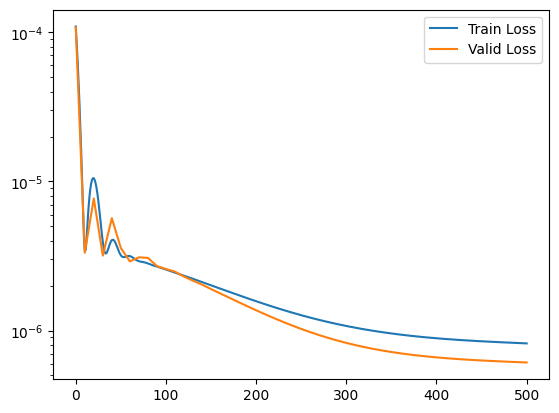

In [4]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()

In [5]:
from util import TestCase

train = TestCase.from_npz(train_datafile)
valid = TestCase.from_npz(valid_datafile)
# train = TestCase.from_npz("output_valid.npz")
# valid = TestCase.from_npz("output_valid.npz")
print("Train:")
print("fixed idx:", train.bc.idx_b)
print("slope:", train.bc.xb_m)
print("intercept:", train.bc.xb_c)
print("Valid:")
print("fixed idx:", valid.bc.idx_b)
print("slope:", valid.bc.xb_m)
print("intercept:", valid.bc.xb_c)
lambdas = jnp.linspace(0.0, 1.0, valid.qs.shape[1])
print("lambdas: ", lambdas)


Train:
fixed idx: [ 0  1  2  3  7  8  9 10]
slope: [[[ 0.    0.    0.    0.    0.   -0.1   0.   -0.05]]

 [[ 0.    0.    0.    0.    0.    0.08  0.    0.04]]

 [[ 0.    0.    0.    0.    0.    0.06  0.   -0.03]]

 [[ 0.    0.    0.    0.    0.   -0.04  0.    0.02]]

 [[ 0.    0.    0.    0.    0.   -0.02  0.   -0.01]]]
intercept: [0.  0.  0.  0.  0.  0.5 0.  0. ]
Valid:
fixed idx: [ 0  1  2  3  7  8  9 10]
slope: [[[ 0.    0.    0.    0.    0.   -0.12  0.    0.01]]

 [[ 0.    0.    0.    0.    0.   -0.1   0.   -0.02]]

 [[ 0.    0.    0.    0.    0.   -0.08  0.    0.03]]

 [[ 0.    0.    0.    0.    0.    0.06  0.   -0.04]]

 [[ 0.    0.    0.    0.    0.    0.04  0.    0.05]]]
intercept: [0.  0.  0.  0.  0.  0.5 0.  0. ]
lambdas:  [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [6]:

print(valid.bc)
base, aux, _ = get_base_rod()
rods = base.with_bc(valid.bc)
pred = rods.solve(final_model, lambdas, aux, max_dlambda=5e-3, iters=5, ls_steps=10)
print(pred.shape)
print(valid.qs.shape)
print(train.qs.shape)
# animate(pred)

BatchedLinearBC(idx_b=i64[8](numpy), xb_m=f64[5,1,8](numpy), xb_c=f64[8](numpy))
(5, 11, 11)
(5, 11, 11)
(5, 11, 11)


In [7]:
# animate(valid.qs)

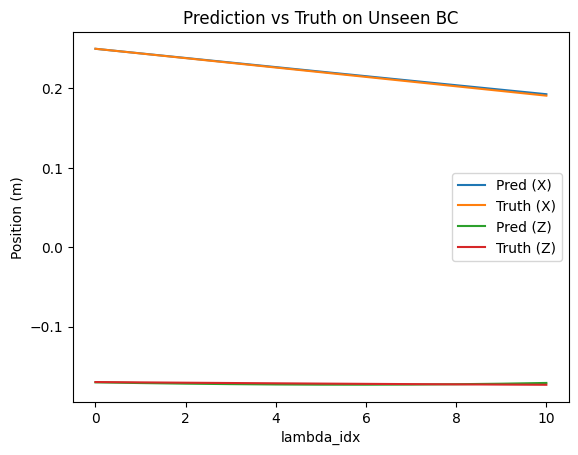

In [8]:
import matplotlib.pyplot as plt

plt.plot(pred[0,:, 4], label="Pred (X)")
plt.plot(valid.qs[0,:, 4], label="Truth (X)")
# plt.plot(pred[:,:, 5], label="Pred (Y)")
# plt.plot(valid.qs[:,:, 5], label="Truth (Y)")
plt.plot(pred[0,:, 6], label="Pred (Z)")
plt.plot(valid.qs[0,:, 6], label="Truth (Z)")
plt.legend()
plt.title("Prediction vs Truth on Unseen BC")
plt.xlabel("lambda_idx")
plt.ylabel("Position (m)")
plt.show()

In [9]:
print("Training BC:")
print("init: ", train.qs[0, 8:11])
print("final: ", train.qs[-1, 8:11])

print("Validation BC:")
print("init: ", valid.qs[0, 8:11])
print("final: ", valid.qs[-1, 8:11])

Training BC:
init:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.06445734e-01  5.23079694e-05 -1.95548770e-01  0.00000000e+00
   4.20000000e-01  0.00000000e+00 -4.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.00984620e-01  5.92194272e-05 -1.98657304e-01  0.00000000e+00
   4.10000000e-01  0.00000000e+00 -4.50000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.95521151e-01  6.64904575e-05 -2.01744441e-01  0.00000000e+00
   4.00000000e-01  0.00000000e+00 -5.00000000e-02]]
final:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.41318959e-01  1.17278652e-05 -1.75167912e-01  0.00000000e+00
   4.84000000e-01  0.00000000e+00 -8.00000000e-03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.40231505e-01  1.27490086e-05 -1.75817024e-01  0.00000000e+00
   4.82000000e-01  0.00000000e+00 -9.00000000e-03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.000

In [10]:
print("initial position of the middle node in the training data: ", train.qs[0, 4:7])
print("final position of the middle node in the training data: ", train.qs[-1, 4:7])

initial position of the middle node in the training data:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.28259057e-01  2.73439887e-05 -1.82906749e-01  0.00000000e+00
   4.60000000e-01  0.00000000e+00 -2.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.22810780e-01  3.31527109e-05 -1.86097787e-01  0.00000000e+00
   4.50000000e-01  0.00000000e+00 -2.50000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.17359081e-01  3.92855092e-05 -1.89268693e-01  0.00000000e+00
   4.40000000e-01  0.00000000e+00 -3.00000000e-02]]
final position of the middle node in the training data:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.45666605e-01  7.66317650e-06 -1.72563975e-01  0.00000000e+00
   4.92000000e-01  0.00000000e+00 -4.00000000e-03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.44579873e-01  8.64809213e-06 -1.73216088e-01  0.00000000e+00
   4.90000000e-01  

In [11]:
print("initial position of the middle node in the validation data: ", valid.qs[0, 4:7])
print("final position of the middle node in the validation data: ", valid.qs[-1, 4:7])

initial position of the middle node in the validation data:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.26363448e-01  1.98301625e-06 -1.71545938e-01  0.00000000e+00
   4.52000000e-01  0.00000000e+00  4.00000000e-03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.20454157e-01  7.04339092e-07 -1.71901769e-01  0.00000000e+00
   4.40000000e-01  0.00000000e+00  5.00000000e-03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.14545544e-01 -7.07033089e-07 -1.72239267e-01  0.00000000e+00
   4.28000000e-01  0.00000000e+00  6.00000000e-03]]
final position of the middle node in the validation data:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.59689466e-01 -2.36458745e-05 -1.58634358e-01  0.00000000e+00
   5.16000000e-01  0.00000000e+00  2.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.62109239e-01 -2.80949701e-05 -1.55783211e-01  0.00000000e+00
   5.20000000e-

In [12]:
print("initial position of the middle node in the prediction: ", pred[0, 4:7])
print("final position of the middle node in the prediction: ", pred[-1, 4:7])

initial position of the middle node in the prediction:  [[ 0.          0.          0.          0.          0.2269188   0.
  -0.17301022  0.          0.452       0.          0.004     ]
 [ 0.          0.          0.          0.          0.22118577  0.
  -0.17325489  0.          0.44        0.          0.005     ]
 [ 0.          0.          0.          0.          0.21546834  0.
  -0.17329673  0.          0.428       0.          0.006     ]]
final position of the middle node in the prediction:  [[ 0.          0.          0.          0.          0.26183526  0.
  -0.1581615   0.          0.516       0.          0.02      ]
 [ 0.          0.          0.          0.          0.26473496  0.
  -0.15504318  0.          0.52        0.          0.025     ]
 [ 0.          0.          0.          0.          0.2676107   0.
  -0.15189717  0.          0.524       0.          0.03      ]]
